# Ablação H2 — TF-IDF no `titulo_do_projeto`

Este notebook testa a hipótese H2:
"A extração de características textuais melhora significativamente a capacidade preditiva do modelo"

## Estratégia
Treinamos 3 modelos (LightGBM, Random Forest, TabPFN-3) cada um em duas versões:

| Versão | `linha_de_fomento`, `tipo_modalidade`, `area`, `subarea`, `sigla_uf_origem` | `titulo_do_projeto` |
|--------|----------------------------------------------------------------------------|---------------------|
| SEM TF-IDF | OrdinalEncoder (como qualquer categórica) | TargetEncoder |
| COM TF-IDF | TfidfVectorizer (300 features, bigramas)  | TargetEncoder |

`titulo_do_projeto` sempre vai para TargetEncoder — não faz parte da ablação.  
Tudo mais é idêntico: mesma amostra (30k), mesmo split, mesmo seed.

## 1. Imports e configurações

In [19]:
import warnings
warnings.filterwarnings('ignore')

import re, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

os.environ['TABPFN_ALLOW_CPU_LARGE_DATASET'] = '1'

print('Imports OK')

Imports OK


In [ ]:
# ── Configurações globais ──────────────────────────────────────────────────
ARQUIVO_PARQUET = 'dados/cnpqBolsasAuxilios_limpo.parquet'
TARGET          = 'valor_pago'
N_SAMPLE        = 300_000
RANDOM_STATE    = 67

# Hiperparâmetros fixos — sem Optuna para comparação justa
LGB_PARAMS = dict(
    n_estimators=800, learning_rate=0.05, num_leaves=127,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

RF_PARAMS = dict(
    n_estimators=300, max_depth=15, min_samples_leaf=5,
    max_features='sqrt', n_jobs=-1, random_state=RANDOM_STATE,
)

# TabPFN -> max 10k linhas de treino por limitação do modelo
TABPFN_MAX_TRAIN = 10_000
TFIDF_MAX_TABPFN = 20   

print(f'N_SAMPLE = {N_SAMPLE:,}')

N_SAMPLE = 300,000


## 2. Carregamento e pré-processamento

In [21]:
print('Carregando dataset...')
df_full = pd.read_parquet(ARQUIVO_PARQUET)
print(f'Shape original: {df_full.shape}')

n  = min(N_SAMPLE, len(df_full))
df = df_full.sample(n=n, random_state=RANDOM_STATE).copy()
print(f'Shape após amostragem: {df.shape}')

if '_record_number' in df.columns:
    df = df.drop(columns=['_record_number'])

y_num = pd.to_numeric(df[TARGET], errors='coerce')
teto  = y_num.quantile(0.95)
df    = df[y_num <= teto].copy()
print(f'Teto p95: R$ {teto:,.2f}  |  Shape após corte: {df.shape}')

Carregando dataset...
Shape original: (3274778, 27)
Shape após amostragem: (300000, 27)
Teto p95: R$ 33,600.00  |  Shape após corte: (285167, 26)


## 3. Feature engineering

In [22]:
NIVEL_MAP = {
    '1A': 9, '1B': 8, '1C': 7, '1D': 6,
    '2': 5,  '2A': 5, '2B': 4,
    'DT-1A': 9, 'DT-1B': 8, 'DT-2': 5,
    'PDS': 6, 'PDJ': 6,
    'DO': 4, 'DS': 4, 'GD': 4, 'SWE': 4,
    'ME': 3, 'MS': 3,
    'IC': 2, 'ITI': 2, 'AT': 2,
    'B': 3, 'A': 2, 'C': 1,
}

def map_nivel(s):
    if pd.isna(s) or str(s).strip() in ('', 'nulo', 'nan'):
        return 0
    s = str(s).strip().upper()
    if s in NIVEL_MAP: return NIVEL_MAP[s]
    s2 = s.replace(' ', '')
    if s2 in NIVEL_MAP: return NIVEL_MAP[s2]
    m = re.search(r'(\d+[A-D]?)', s)
    if m and m.group(1) in NIVEL_MAP: return NIVEL_MAP[m.group(1)]
    return 0

df['nivel_ordinal']           = df['categoria_nivel'].apply(map_nivel)
df['ano_referencia']          = pd.to_numeric(df['ano_referencia'], errors='coerce').fillna(2020)
df['anos_desde_2000']         = df['ano_referencia'] - 2000
df['natureza_de_despesa_str'] = df['natureza_de_despesa'].fillna(-1).astype(int).astype(str)

print('Feature engineering concluído.')

Feature engineering concluído.


## 4. Split treino / teste (70/30)

In [23]:
def sanitize_target(X_df, y_series):
    y_num    = pd.to_numeric(y_series, errors='coerce')
    mask     = y_num.notna() & (y_num > 0)
    X_c, y_c = X_df.loc[mask].copy(), y_num.loc[mask].copy()
    y_log    = np.log1p(y_c)
    fin_mask = np.isfinite(y_log)
    return X_c.loc[fin_mask].copy(), y_c.loc[fin_mask].copy()

y_raw    = df[TARGET]
X        = df.drop(columns=[TARGET])
X, y_raw = sanitize_target(X, y_raw)

cat_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

for c in cat_cols:
    X[c] = X[c].fillna('nulo').astype(str)
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0)

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y_raw, test_size=0.30, random_state=RANDOM_STATE
)
y_train = np.log1p(y_train_raw.values)
y_test  = np.log1p(y_test_raw.values)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (199425, 28) | Teste: (85468, 28)


## 5. Funções auxiliares

In [ ]:
resultados_ablacao = []

def avaliar(nome, pred_log, y_test_log, y_test_real):
    pred_real = np.expm1(pred_log)
    mae     = mean_absolute_error(y_test_real, pred_real)
    rmse    = math.sqrt(mean_squared_error(y_test_real, pred_real))
    r2_real = r2_score(y_test_real, pred_real)
    r2_log  = r2_score(y_test_log, pred_log)
    print(f'\n{"="*50}\nRESULTADOS — {nome}\n{"="*50}')
    print(f'MAE    : R$ {mae:>10,.2f}')
    print(f'RMSE   : R$ {rmse:>10,.2f}')
    print(f'R² real: {r2_real:.4f}')
    print(f'R² log : {r2_log:.4f}')
    resultados_ablacao.append({
        'Modelo': nome, 'MAE': mae, 'RMSE': rmse,
        'R²_real': r2_real, 'R²_log': r2_log
    })
    return pred_real


def build_preprocessor(usar_tfidf, max_features_tfidf=300):
    
    """
    usar_tfidf=True  → linha_de_fomento, tipo_modalidade, area, subarea,
                        sigla_uf_origem são vetorizadas com TF-IDF.
    usar_tfidf=False → essas colunas vão para OrdinalEncoder como qualquer
                        outra categórica de baixa cardinalidade.
    titulo_do_projeto sempre vai para TargetEncoder, em ambos os casos.
    """

    TFIDF_CANDIDATES = ['linha_de_fomento', 'tipo_modalidade', 'area',
                        'subarea', 'sigla_uf_origem']

    tfidf_cols = ([c for c in TFIDF_CANDIDATES if c in X_train.columns]
                  if usar_tfidf else [])

    high_cols  = [c for c in [
                    'modalidade', 'programa_cnpq', 'instituicao_origem',
                    'categoria', 'palavra_chave', 'titulo_do_projeto',
                    'uo', 'natureza_de_despesa'
                  ] if c in X_train.columns and c not in tfidf_cols]

    low_cols   = [c for c in cat_cols
                  if c not in tfidf_cols and c not in high_cols]

    transformers = []
    for col in tfidf_cols:
        transformers.append((f'tfidf_{col}',
                              TfidfVectorizer(max_features=max_features_tfidf,
                                             ngram_range=(1,2), sublinear_tf=True), col))
    if high_cols:
        transformers.append(('target_enc',
                              TargetEncoder(smooth='auto', random_state=RANDOM_STATE), high_cols))
    if low_cols:
        transformers.append(('ordinal_enc',
                              OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), low_cols))
    transformers.append(('num', 'passthrough', num_cols))
    return ColumnTransformer(transformers, remainder='drop')


print('Funções auxiliares definidas.')

Funções auxiliares definidas.


## 6. LightGBM — SEM e COM TF-IDF

- **SEM:** `linha_de_fomento`, `tipo_modalidade`, `area`, `subarea`, `sigla_uf_origem` → OrdinalEncoder  
- **COM:** as mesmas colunas → TfidfVectorizer(300 features, bigramas)

In [25]:
# ── LightGBM SEM TF-IDF ───────────────────────────────────────────────────
pipe_lgb_sem = Pipeline([
    ('preprocessor', build_preprocessor(usar_tfidf=False)),
    ('model', LGBMRegressor(**LGB_PARAMS))
])
print('Treinando LightGBM SEM TF-IDF...')
pipe_lgb_sem.fit(X_train, y_train)
pred = pipe_lgb_sem.predict(X_test)
avaliar('LightGBM — SEM TF-IDF', pred, y_test, y_test_raw.values)

Treinando LightGBM SEM TF-IDF...

RESULTADOS — LightGBM — SEM TF-IDF
MAE    : R$   3,079.80
RMSE   : R$   5,143.70
R² real: 0.6128
R² log : 0.7389


array([2467.40982112,  925.48191686, 9685.01313078, ..., 1672.35750231,
       2960.35358117, 9320.70977405], shape=(85468,))

In [26]:
# ── LightGBM COM TF-IDF ───────────────────────────────────────────────────
pipe_lgb_com = Pipeline([
    ('preprocessor', build_preprocessor(usar_tfidf=True)),
    ('model', LGBMRegressor(**LGB_PARAMS))
])
print('Treinando LightGBM COM TF-IDF...')
pipe_lgb_com.fit(X_train, y_train)
pred = pipe_lgb_com.predict(X_test)
avaliar('LightGBM — COM TF-IDF', pred, y_test, y_test_raw.values)

Treinando LightGBM COM TF-IDF...

RESULTADOS — LightGBM — COM TF-IDF
MAE    : R$   3,087.69
RMSE   : R$   5,151.32
R² real: 0.6116
R² log : 0.7384


array([ 2474.09430925,   960.13214151, 10404.72923581, ...,
        1907.16360708,  2941.16736307,  9382.83019927], shape=(85468,))

## 7. Random Forest — SEM e COM TF-IDF

Mesma lógica do LightGBM. Random Forest lida bem com matrizes esparsas via scikit-learn.

In [27]:
# ── Random Forest SEM TF-IDF ──────────────────────────────────────────────
pipe_rf_sem = Pipeline([
    ('preprocessor', build_preprocessor(usar_tfidf=False)),
    ('model', RandomForestRegressor(**RF_PARAMS))
])
print('Treinando Random Forest SEM TF-IDF...')
pipe_rf_sem.fit(X_train, y_train)
pred = pipe_rf_sem.predict(X_test)
avaliar('Random Forest — SEM TF-IDF', pred, y_test, y_test_raw.values)

Treinando Random Forest SEM TF-IDF...

RESULTADOS — Random Forest — SEM TF-IDF
MAE    : R$   3,126.98
RMSE   : R$   5,188.95
R² real: 0.6059
R² log : 0.7367


array([2490.11427681,  940.36632592, 7910.60944319, ..., 1645.21230698,
       2876.20651084, 9917.78225777], shape=(85468,))

In [28]:
# ── Random Forest COM TF-IDF ──────────────────────────────────────────────
pipe_rf_com = Pipeline([
    ('preprocessor', build_preprocessor(usar_tfidf=True)),
    ('model', RandomForestRegressor(**RF_PARAMS))
])
print('Treinando Random Forest COM TF-IDF...')
pipe_rf_com.fit(X_train, y_train)
pred = pipe_rf_com.predict(X_test)
avaliar('Random Forest — COM TF-IDF', pred, y_test, y_test_raw.values)

Treinando Random Forest COM TF-IDF...

RESULTADOS — Random Forest — COM TF-IDF
MAE    : R$   3,335.41
RMSE   : R$   5,581.20
R² real: 0.5441
R² log : 0.7144


array([2487.40223059, 1035.68686106, 8004.70595504, ..., 1735.58167122,
       2540.97067843, 8925.94945501], shape=(85468,))

## 8. TabPFN — SEM e COM TF-IDF

> **Nota:** TabPFN suporta no máximo ~10k linhas de treino e ~200 features no total.  
> Com TF-IDF limitamos a 20 features por coluna para não estourar esse limite.

In [29]:
from tabpfn_client import TabPFNRegressor

class DenseTransformer:
    """Converte matriz esparsa para densa (exigido pelo TabPFN)."""
    def fit(self, X, y=None):         return self
    def fit_transform(self, X, y=None): return self.transform(X)
    def transform(self, X):
        return X.toarray() if hasattr(X, 'toarray') else X

# Subamostra para o TabPFN
idx_sub = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(TABPFN_MAX_TRAIN, len(X_train)), replace=False
)
X_train_tab  = X_train.iloc[idx_sub]
y_train_tab  = y_train[idx_sub]

print(f'TabPFN treino: {X_train_tab.shape}')

TabPFN treino: (10000, 28)


In [30]:
# ── TabPFN SEM TF-IDF ─────────────────────────────────────────────────────
pipe_tab_sem = Pipeline([
    ('preprocessor', build_preprocessor(usar_tfidf=False, max_features_tfidf=TFIDF_MAX_TABPFN)),
    ('to_dense', DenseTransformer()),
    ('model', TabPFNRegressor(random_state=RANDOM_STATE))
])
print('Treinando TabPFN SEM TF-IDF...')
pipe_tab_sem.fit(X_train_tab, y_train_tab)
pred = pipe_tab_sem.predict(X_test)
avaliar('TabPFN — SEM TF-IDF', pred, y_test, y_test_raw.values)

Treinando TabPFN SEM TF-IDF...
00:07 Fitting... Done!
00:15 Predicting... Done!

RESULTADOS — TabPFN — SEM TF-IDF
MAE    : R$   3,121.65
RMSE   : R$   5,174.11
R² real: 0.6082
R² log : 0.7248


array([2313.51930677, 1231.08212302, 8545.00192583, ..., 2107.18882333,
       3433.92488093, 9827.15510536], shape=(85468,))

In [31]:
# ── TabPFN COM TF-IDF ─────────────────────────────────────────────────────
pipe_tab_com = Pipeline([
    ('preprocessor', build_preprocessor(usar_tfidf=True, max_features_tfidf=TFIDF_MAX_TABPFN)),
    ('to_dense', DenseTransformer()),
    ('model', TabPFNRegressor(random_state=RANDOM_STATE))
])
print('Treinando TabPFN COM TF-IDF...')
pipe_tab_com.fit(X_train_tab, y_train_tab)
pred = pipe_tab_com.predict(X_test)
avaliar('TabPFN — COM TF-IDF', pred, y_test, y_test_raw.values)

Treinando TabPFN COM TF-IDF...
00:07 Fitting... Done!
00:24 Predicting... Done!

RESULTADOS — TabPFN — COM TF-IDF
MAE    : R$   3,133.82
RMSE   : R$   5,191.91
R² real: 0.6055
R² log : 0.7241


array([2440.34154893, 1286.45638424, 8012.49331983, ..., 2012.21197848,
       3464.0163873 , 9406.37351114], shape=(85468,))

## 9. Comparativo final

In [32]:
df_res = pd.DataFrame(resultados_ablacao)

# Calcula delta (com - sem) para cada modelo
modelos_base = ['LightGBM', 'Random Forest', 'TabPFN']
deltas = {}
for m in modelos_base:
    sem = next(r for r in resultados_ablacao if r['Modelo'] == f'{m} — SEM TF-IDF')
    com = next(r for r in resultados_ablacao if r['Modelo'] == f'{m} — COM TF-IDF')
    deltas[m] = {
        'Δ R²_real': com['R²_real'] - sem['R²_real'],
        'Δ MAE':     com['MAE']     - sem['MAE'],
    }

print('\n' + '='*70)
print('COMPARATIVO ABLAÇÃO H2 — SEM vs COM TF-IDF')
print('='*70)
df_display = df_res.copy()
df_display['MAE']  = df_display['MAE'].map('R$ {:,.2f}'.format)
df_display['RMSE'] = df_display['RMSE'].map('R$ {:,.2f}'.format)
print(df_display.to_string(index=False))

print('\n' + '='*70)
print('DELTA (COM − SEM TF-IDF) por modelo')
print('='*70)
for m, d in deltas.items():
    sinal = 'GANHO ✓' if d['Δ R²_real'] > 0.01 else ('leve ganho' if d['Δ R²_real'] > 0 else 'sem ganho')
    print(f'{m:<15}  Δ R²={d["Δ R²_real"]:+.4f}   Δ MAE=R$ {d["Δ MAE"]:+,.2f}   [{sinal}]')


COMPARATIVO ABLAÇÃO H2 — SEM vs COM TF-IDF
                    Modelo         MAE        RMSE  R²_real   R²_log
     LightGBM — SEM TF-IDF R$ 3,079.80 R$ 5,143.70 0.612754 0.738857
     LightGBM — COM TF-IDF R$ 3,087.69 R$ 5,151.32 0.611606 0.738358
Random Forest — SEM TF-IDF R$ 3,126.98 R$ 5,188.95 0.605910 0.736685
Random Forest — COM TF-IDF R$ 3,335.41 R$ 5,581.20 0.544078 0.714389
       TabPFN — SEM TF-IDF R$ 3,121.65 R$ 5,174.11 0.608161 0.724776
       TabPFN — COM TF-IDF R$ 3,133.82 R$ 5,191.91 0.605460 0.724144

DELTA (COM − SEM TF-IDF) por modelo
LightGBM         Δ R²=-0.0011   Δ MAE=R$ +7.90   [sem ganho]
Random Forest    Δ R²=-0.0618   Δ MAE=R$ +208.44   [sem ganho]
TabPFN           Δ R²=-0.0027   Δ MAE=R$ +12.17   [sem ganho]


## 10. Gráfico comparativo

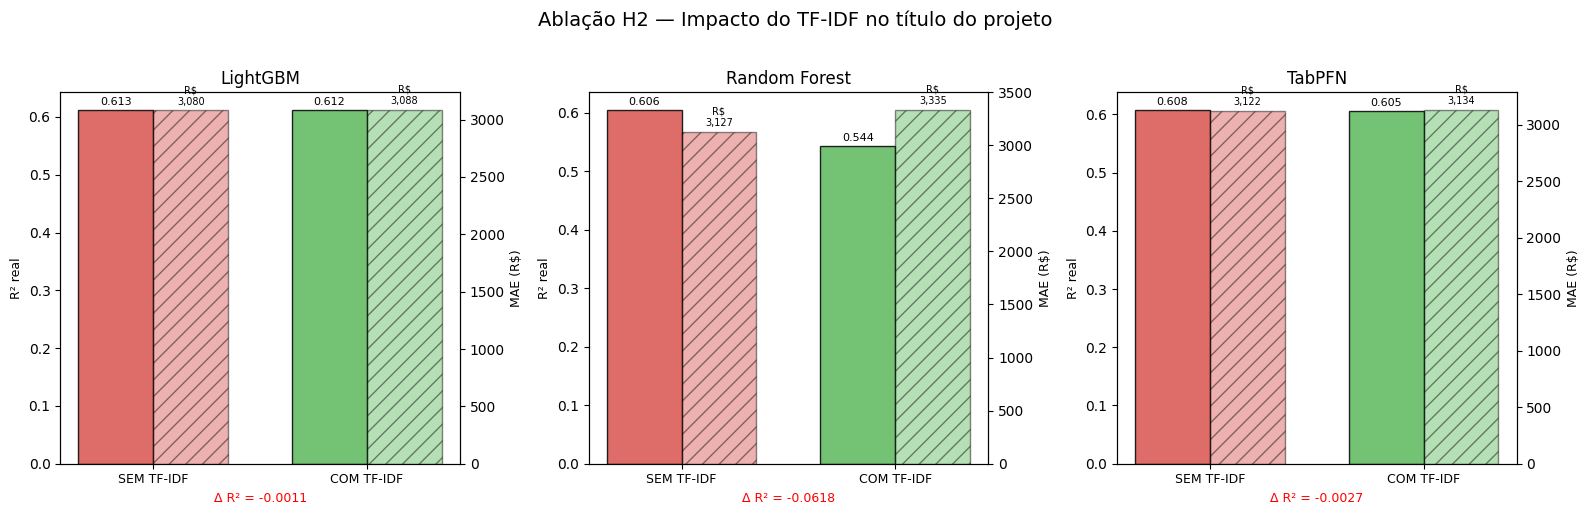

Gráfico salvo como ablacao_h2_tfidf.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ablação H2 — Impacto do TF-IDF no título do projeto', fontsize=14, y=1.02)

cores = {'SEM TF-IDF': '#d9534f', 'COM TF-IDF': '#5cb85c'}

for ax, modelo in zip(axes, modelos_base):
    r2_vals  = []
    mae_vals = []
    labels   = ['SEM TF-IDF', 'COM TF-IDF']
    for v in labels:
        r = next(x for x in resultados_ablacao if x['Modelo'] == f'{modelo} — {v}')
        r2_vals.append(r['R²_real'])
        mae_vals.append(r['MAE'])

    x     = np.arange(len(labels))
    width = 0.35
    b1    = ax.bar(x - width/2, r2_vals,  width, label='R² real',
                   color=[cores[l] for l in labels], alpha=0.85, edgecolor='black')
    ax2   = ax.twinx()
    b2    = ax2.bar(x + width/2, mae_vals, width, label='MAE (R$)',
                    color=[cores[l] for l in labels], alpha=0.45, edgecolor='black', hatch='//')

    ax.set_title(modelo, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('R² real', fontsize=9)
    ax2.set_ylabel('MAE (R$)', fontsize=9)

    for bar, val in zip(b1, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(b2, mae_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(mae_vals)*0.01,
                 f'R$\n{val:,.0f}', ha='center', va='bottom', fontsize=7)

    delta_r2 = r2_vals[1] - r2_vals[0]
    cor_delta = 'green' if delta_r2 > 0 else 'red'
    ax.set_xlabel(f'Δ R² = {delta_r2:+.4f}', color=cor_delta, fontsize=9)

plt.tight_layout()
plt.savefig('figures/ablacao_h2_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo como figures/ablacao_h2_tfidf.png')